In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import torchvision

In [2]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
device

device(type='mps')

# Import the data

In [3]:
trainOrgData = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=None)
testOrgData = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=None)


In [4]:
trainOrgData.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [5]:
# Extract trouser, pullover, sneaker only

idxTrain = (trainOrgData.targets == 1) | (trainOrgData.targets == 2) | (trainOrgData.targets == 7)
idxTest = (testOrgData.targets == 1) | (testOrgData.targets == 2) | (testOrgData.targets == 7)

trainData = trainOrgData.data[idxTrain]
testData = testOrgData.data[idxTest]

trainData = trainData / torch.max(testData)
trainData = 2*trainData - 1
trainData = trainData

testData = testData / torch.max(testData)
testData = 2*testData - 1
testData = testData

In [6]:
trainData[0], testData[0], type(trainData[0]), trainData[0].dtype, trainData[0].max(), trainData[0].min(), trainData.size()

(tensor([[-1.0000, -1.0000, -1.0000, -1.0000, -0.9922, -1.0000, -1.0000, -1.0000,
          -1.0000, -0.8275, -0.3098,  0.4745,  0.3490,  0.0353, -0.0196,  0.1059,
           0.5608,  0.1216, -0.9294, -1.0000, -1.0000, -1.0000, -0.9922, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -0.9922, -1.0000, -1.0000, -0.8431,  0.0275,
           0.5608,  0.6157,  0.5373,  0.5843,  0.8980,  1.0000,  1.0000,  0.9608,
           0.7412,  0.5451,  0.6157,  0.4745, -0.0118, -0.8667, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -0.9922, -1.0000, -0.7255,  0.6784,  0.4980,
           0.4353,  0.3961,  0.3725,  0.3176,  0.1765,  0.2706,  0.2471,  0.1922,
           0.2392,  0.4039,  0.4353,  0.4824,  0.5294,  0.4510, -0.3569, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000,  0.3333,  0.4902,  0.3490,
           0.3882,  0.3804,  0.3412,  0

# Create the Data Loader

In [7]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(trainData, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(testData, batch_size=batch_size, shuffle=True)

# Create classes for the discriminator and generator

In [8]:
class discriminatorNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 256)
        self.out = nn.Linear(256, 1)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = self.out(x)
        return torch.sigmoid(x)

dnet = discriminatorNet()
dnet.to(device)

y = dnet(torch.randn(5, 28*28).to(device))
y

tensor([[0.5034],
        [0.4290],
        [0.5169],
        [0.5039],
        [0.5354]], device='mps:0', grad_fn=<SigmoidBackward0>)

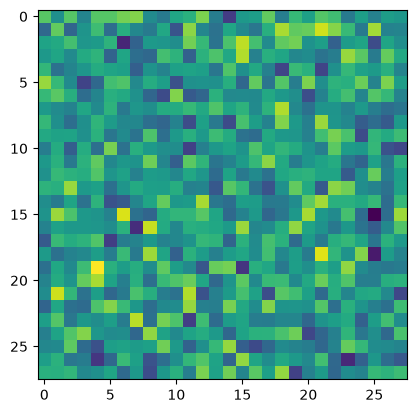

In [9]:
class generatorNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(64, 256)
        self.fc2 = nn.Linear(256, 256)
        self.out = nn.Linear(256, 28*28)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = self.out(x)
        return torch.tanh(x)

gnet = generatorNet()
gnet.to(device)
y = gnet(torch.randn(5, 64).to(device))
plt.imshow(y[0].detach().cpu().view(28,28))

# Train the model

In [10]:
loss_fn = nn.BCELoss()
d_optimizer = torch.optim.Adam(dnet.parameters(), lr=0.001)
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=0.001)


# Training Loop

In [11]:
epochs = 50000

losses = np.zeros((epochs,2))
disDecs = np.zeros((epochs,2))

for epoch in range(epochs):
    for x in train_loader:
        real_images = x.to(device).reshape(-1,28*28)
        fake_images = gnet(torch.randn(batch_size,64).to(device))

        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)

#----------------- Train the discriminator ------------------#
        pred_real = dnet(real_images)
        d_loss_real = loss_fn(pred_real, real_labels)

        pred_fake = dnet(fake_images)
        d_loss_fake = loss_fn(pred_fake, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        losses[epoch,0] = d_loss.item()
        disDecs[epoch,0] = torch.mean((pred_real>0.5).float()).detach()

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

#----------------- Train the Generator ------------------#
        fake_images = gnet(torch.randn(batch_size,64).to(device))
        pred_fake = dnet(fake_images)

        g_loss = loss_fn(pred_fake, real_labels)
        losses[epoch,1] = g_loss.item()
        disDecs[epoch,1] = torch.mean((pred_real>0.5).float()).detach()

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    #if (epoch+1)%500==0:
    msg = f'Epoch {epoch+1}/{epochs}'
    print(msg)

Epoch 1/50000
Epoch 2/50000
Epoch 3/50000
Epoch 4/50000
Epoch 5/50000
Epoch 6/50000
Epoch 7/50000
Epoch 8/50000
Epoch 9/50000
Epoch 10/50000
Epoch 11/50000


KeyboardInterrupt: 

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(18,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discrimator','Generator'])

ax[1].plot(losses[::5,0],losses[::5,1],'k.',alpha=.1)
ax[1].set_xlabel('Discriminator loss')
ax[1].set_ylabel('Generator loss')

ax[2].plot(disDecs)
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Probablity ("real")')
ax[2].set_title('Discriminator output')
ax[2].legend(['Real','Fake'])

plt.show()

In [ ]:
# generate the images from the generator network
gnet.eval()
fake_data = gnet(torch.randn(12,64).to(device)).cpu()
discriminator = dnet(fake_data.to(device))

# and visualize...
fig,axs = plt.subplots(3,4,figsize=(8,6))
for i,ax in enumerate(axs.flatten()):
  ax.set_title(f'{discriminator[i].item():.2f}')
  ax.imshow(fake_data[i,:,].detach().view(28,28),cmap='gray')
  ax.axis('off')

plt.show()